In [2]:
from osgeo import gdal
import matplotlib.pyplot as plt
import cv2
import numpy as np

**LENDO & VISUALIZANDO ARQUIVO**

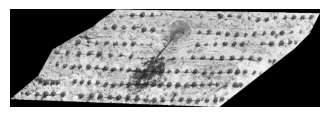

In [5]:
path_amostra_padronizada = '../data/processed/sample2_pad.tif'

# Abrir arquivo TIFF com GDAL
src = gdal.Open(path_amostra_padronizada, gdal.GA_ReadOnly)
gt = src.GetGeoTransform()

# Converter para numpy
img_gray = src.ReadAsArray()

plt.figure(figsize=(4,4))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

**HISTOGRAMA**

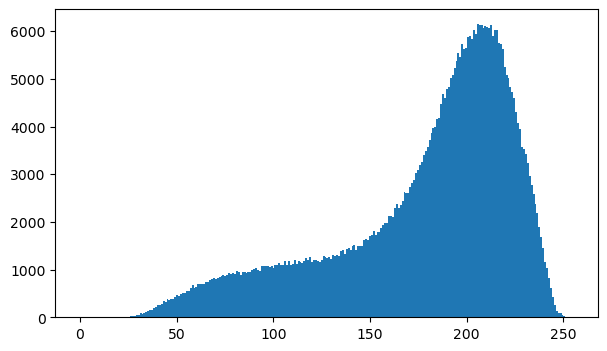

In [6]:
img_hist = img_gray[img_gray > 0] # removendo as bordas pretas do mosaico

plt.figure(figsize=(7,4))
plt.hist(img_hist.ravel(), bins=256, range=(0, 255))
plt.show()

**GERANDO MÁSCARA DE SEGMENTAÇÃO**

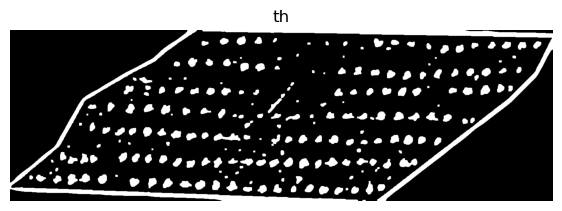

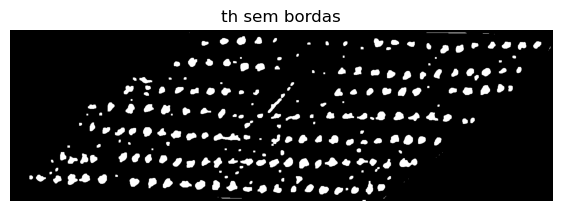

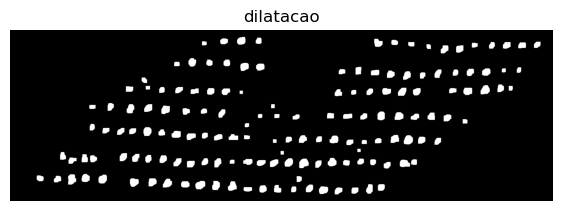

In [10]:
kernel = np.ones((5,5), np.uint8)

clean = cv2.bilateralFilter(img_gray, d=9, sigmaColor=75, sigmaSpace=75)
bg = cv2.GaussianBlur(clean, (61, 61), 0)
fg = cv2.subtract(bg, clean)
blur = cv2.GaussianBlur(fg, (11, 11), 0)

_, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)

cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

h_tile, w_tile = th.shape

th_borderless = th.copy()
for c in cnts:
    area_c = cv2.contourArea(c)
    if area_c == 0: continue
    
    x_r, y_r, w_r, h_r = cv2.boundingRect(c)
    peri = cv2.arcLength(c, True)

    is_at_edge = (x_r <= 2 or y_r <= 2 or x_r + w_r >= w_tile - 2 or y_r + h_r >= h_tile - 2)
    
    is_very_long = (w_r > w_tile * 0.5) or (h_r > h_tile * 0.5)
    
    circularidade = (4 * np.pi * area_c) / (peri ** 2)
    
    if is_at_edge and (is_very_long or circularidade < 0.2):
        cv2.drawContours(th_borderless, [c], -1, 0, thickness=12)

erosao = cv2.erode(th_borderless, kernel, iterations=2)
dilatacao = cv2.dilate(erosao, kernel, iterations=2)

plt.figure(figsize=(7,4))
plt.title('th')
plt.axis('off')
plt.imshow(th, cmap='gray')

plt.figure(figsize=(7,4))
plt.title('th sem bordas')
plt.axis('off')
plt.imshow(th_borderless, cmap='gray')

plt.figure(figsize=(7,4))
plt.title('dilatacao')
plt.axis('off')
plt.imshow(dilatacao, cmap='gray')

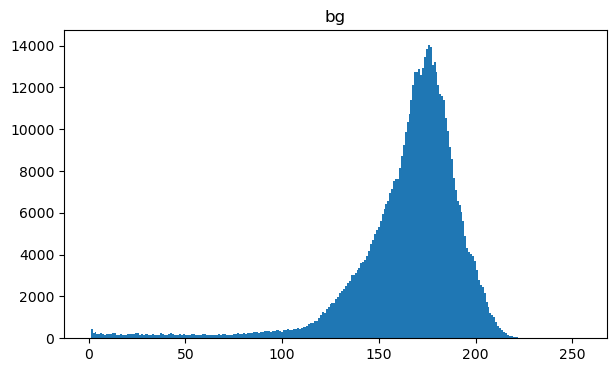

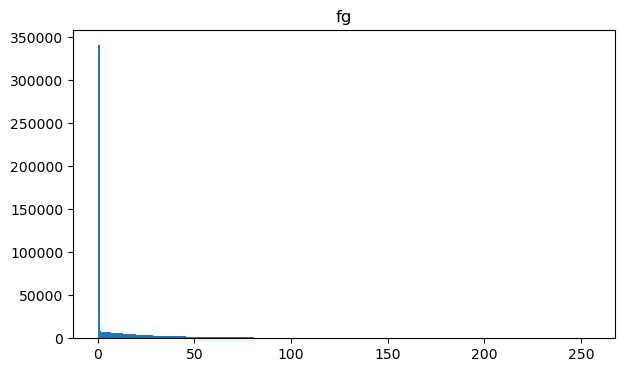

In [19]:
bg = cv2.GaussianBlur(img_gray, (61, 61), 0)   # ajuste o kernel
fg = cv2.subtract(bg, img_gray)                # realça escuros

plt.figure(figsize=(7,4))
plt.title('bg')
plt.hist(bg.ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(7,4))
plt.title('fg')
plt.hist(fg.ravel(), bins=256, range=(0, 255))

plt.show()